### Importing libraries


In [23]:
# Installing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Data collection

In [24]:
df = pd.read_csv('https://raw.githubusercontent.com/Phionanamugga/EDA_Tax_returns/refs/heads/feature1/Casino_Tax_data.csv')

#### Data exploration

In [14]:
# Setting plotting style
sns.set(style="whitegrid")

In [3]:
df.head()

,Fiscal Year,Month Ending,Licensee,Wagers,Patron Winnings,Cancelled Wagers,Online Casino Gaming Win/(Loss),Promotional Coupons or Credits Wagered (3),Promotional Deduction (4),Total Gross Gaming Revenue,Payment (5)
0,2021/22,06/30/2022 12:00:00 AM,Mohegan Tribe On-Reservation,379023,335505,5,43513,6390,6390,37123,6682
1,2021/22,06/30/2022 12:00:00 AM,MPTN On-Reservation,671843,685886,3,-14046,29041,0,-14046,0
2,2021/22,06/30/2022 12:00:00 AM,"MPI Master Wagering License CT, LLC",420056291,406814933,164727,13076631,12372142,3269158,9807473,1765345
3,2021/22,06/30/2022 12:00:00 AM,"Mohegan Digital, LLC",254393582,246515856,11645,7866081,1397441,1397441,6468640,1164355
4,2021/22,05/31/2022 12:00:00 AM,Mohegan Tribe On-Reservation,716607,681306,0,35301,4130,4130,31171,5611


In [4]:
df.describe()

,Wagers,Patron Winnings,Cancelled Wagers,Online Casino Gaming Win/(Loss),Promotional Coupons or Credits Wagered (3),Promotional Deduction (4),Total Gross Gaming Revenue,Payment (5)
count,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02,1.430000e+02
mean,2.742207e+08,2.655218e+08,1.783408e+05,8.520509e+06,2.909760e+06,1.470359e+06,7.050150e+06,1.269229e+06
std,2.815530e+08,2.725166e+08,2.826004e+05,8.921912e+06,5.194974e+06,1.512958e+06,7.483596e+06,1.346855e+06
min,1.145280e+05,1.113650e+05,0.000000e+00,-8.099000e+04,0.000000e+00,0.000000e+00,-8.099000e+04,0.000000e+00
25%,1.407190e+06,1.357855e+06,5.000000e+00,3.713950e+04,1.118100e+04,6.188500e+03,3.172700e+04,5.711000e+03
50%,2.656540e+08,2.575127e+08,3.887000e+03,7.866081e+06,1.065100e+06,1.021521e+06,6.821088e+06,1.227796e+06
75%,5.352846e+08,5.156584e+08,2.913700e+05,1.587461e+07,3.844558e+06,3.071548e+06,1.304302e+07,2.347743e+06
max,7.838842e+08,7.573176e+08,1.133136e+06,2.570443e+07,3.220656e+07,4.163625e+06,2.281557e+07,4.106803e+06


In [6]:
# Checking for all missing values
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 11 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   Fiscal Year                                 143 non-null    object
 1   Month Ending                                143 non-null    object
 2   Licensee                                    143 non-null    object
 3   Wagers                                      143 non-null    int64 
 4   Patron Winnings                             143 non-null    int64 
 5   Cancelled Wagers                            143 non-null    int64 
 6   Online Casino Gaming Win/(Loss)             143 non-null    int64 
 7   Promotional Coupons or Credits Wagered (3)  143 non-null    int64 
 8   Promotional Deduction (4)                   143 non-null    int64 
 9   Total Gross Gaming Revenue                  143 non-null    int64 
 10  Payment (5)               

In [8]:
# checking for the sum of missing values in each column
df.isnull().sum()

Fiscal Year                                   0
Month Ending                                  0
Licensee                                      0
Wagers                                        0
Patron Winnings                               0
Cancelled Wagers                              0
Online Casino Gaming Win/(Loss)               0
Promotional Coupons or Credits Wagered (3)    0
Promotional Deduction (4)                     0
Total Gross Gaming Revenue                    0
Payment (5)                                   0
dtype: int64

array([[<Axes: title={'center': 'Wagers'}>,
        <Axes: title={'center': 'Patron Winnings'}>,
        <Axes: title={'center': 'Cancelled Wagers'}>],
       [<Axes: title={'center': 'Online Casino Gaming Win/(Loss)'}>,
        <Axes: title={'center': 'Promotional Coupons or Credits Wagered (3)'}>,
        <Axes: title={'center': 'Promotional Deduction (4)'}>],
       [<Axes: title={'center': 'Total Gross Gaming Revenue'}>,
        <Axes: title={'center': 'Payment (5)'}>, <Axes: >]], dtype=object)

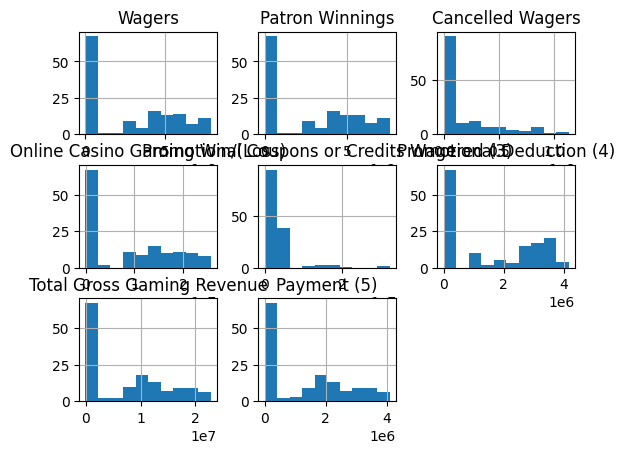

In [ ]:
# visualizing existing columns with histograms
df.hist()


## Data prepprocessing

In [5]:
# Explicitly convert 'Month Ending' to datetime with the correct format
df['Month Ending'] = pd.to_datetime(df['Month Ending'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')

In [6]:
# Converting relevant columns to numeric
numerical_cols = ['Wagers', 'Patron Winnings', 'Cancelled Wagers', 'Online Casino Gaming Win/(Loss)', 
                'Promotional Coupons or Credits Wagered (3)', 'Promotional Deduction (4)', 
                'Total Gross Gaming Revenue', 'Payment (5)']
df[numerical_cols] = df[numerical_cols].apply(pd.to_numeric, errors='coerce')

In [7]:
# Checking for parsing issues
if df['Month Ending'].isnull().any():
    print("Warning: Some 'Month Ending' values could not be parsed. Check the data:")
    print(df[df['Month Ending'].isnull()])

### Data analysis


#### Carries out univariet analysis


Q1: Year-over-Year GGR Growth (%):
Licensee     MPI Master Wagering License CT, LLC  MPTN On-Reservation  \
Fiscal Year                                                             
2021/22                                      NaN                  NaN   
2022/23                                89.084442           315.121164   
2023/24                                45.797119            32.863559   
2024/25                               -54.351860            -1.704212   

Licensee     Mohegan Digital, LLC  Mohegan Tribe On-Reservation  
Fiscal Year                                                      
2021/22                       NaN                           NaN  
2022/23                 94.936503                    147.058307  
2023/24                 46.714726                    184.685822  
2024/25                -48.461418                    -52.047408  


<Figure size 1200x600 with 0 Axes>

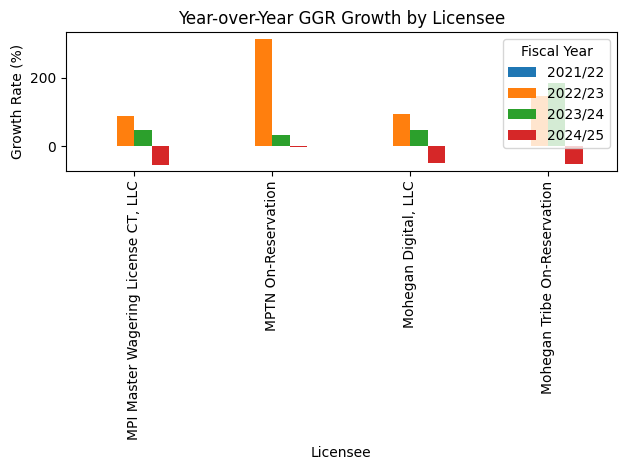

In [ ]:
# What is the year-over-year growth rate in Total Gross Gaming Revenue (GGR) for each licensee, and how does it correlate with Wagers and Online Casino Gaming Win/(Loss)?
# Univariate:Gross Gaming Revenue distribution by fiscal year
fy_ggr = df.groupby(['Fiscal Year', 'Licensee'])['Total Gross Gaming Revenue'].sum().unstack()
ggr_growth = fy_ggr.pct_change() * 100  # Year-over-year growth in %
print("\nQ1: Year-over-Year GGR Growth (%):")
print(ggr_growth)

plt.figure(figsize=(12, 6))
ggr_growth.T.plot(kind='bar')
plt.title('Year-over-Year GGR Growth by Licensee')
plt.xlabel('Licensee')
plt.ylabel('Growth Rate (%)')
plt.legend(title='Fiscal Year')
plt.tight_layout()
plt.show()


Q2: Average Promotional ROI by Licensee:
                              Licensee  Promo ROI
0  MPI Master Wagering License CT, LLC   3.354843
1                  MPTN On-Reservation   2.931480
2                 Mohegan Digital, LLC   4.655583
3         Mohegan Tribe On-Reservation   3.769415


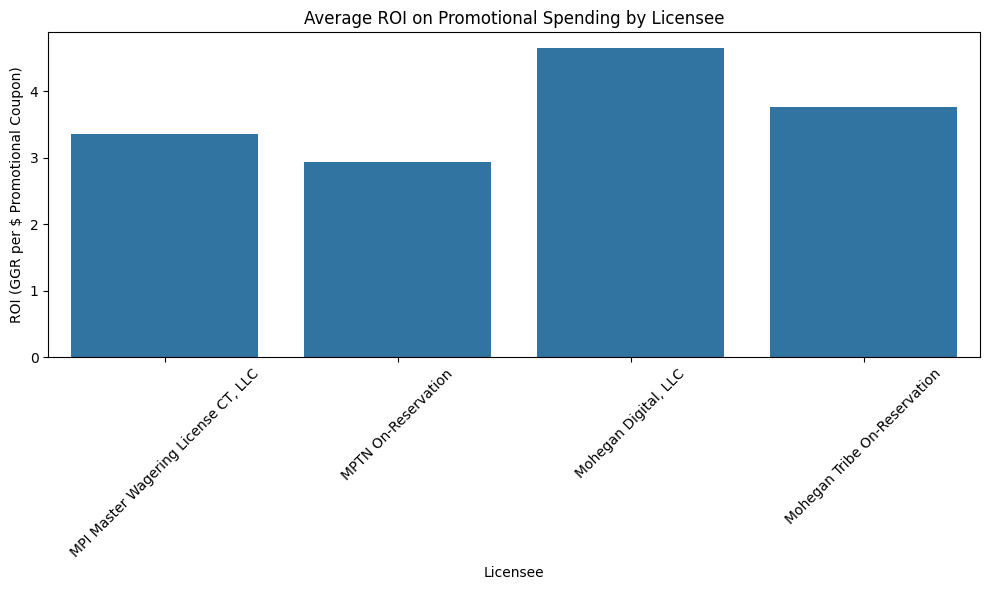

In [10]:
# How does the return on promotional investment (ROI) vary across licensees, considering Promotional Coupons Wagered versus the resulting increase in Wagers and GGR?
# ROI on Promotional Investment
df['Promo ROI'] = (df['Total Gross Gaming Revenue'] / df['Promotional Coupons or Credits Wagered (3)']).replace([float('inf'), -float('inf')], 0)
promo_roi_summary = df.groupby('Licensee')['Promo ROI'].mean().reset_index()
print("\nQ2: Average Promotional ROI by Licensee:")
print(promo_roi_summary)

plt.figure(figsize=(10, 6))
sns.barplot(data=promo_roi_summary, x='Licensee', y='Promo ROI')
plt.title('Average ROI on Promotional Spending by Licensee')
plt.xlabel('Licensee')
plt.ylabel('ROI (GGR per $ Promotional Coupon)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# Which licensee achieves the highest profit margin (Payment as a percentage of GGR) after accounting for the 18% State payment rate, and what factors contribute to this?
# Profit Margin (Payment/GGR)
df['Profit Margin'] = (1 - (df['Payment (5)'] / df['Total Gross Gaming Revenue'])) * 100  # After 18% payment
df['Profit Margin'] = df['Profit Margin'].replace([float('inf'), -float('inf')], 0).fillna(0)
margin_summary = df.groupby('Licensee')['Profit Margin'].mean().reset_index()
print("\nQ3: Average Profit Margin After State Payment by Licensee (%):")
print(margin_summary)


Q3: Average Profit Margin After State Payment by Licensee (%):
                              Licensee  Profit Margin
0  MPI Master Wagering License CT, LLC      82.000000
1                  MPTN On-Reservation      83.999936
2                 Mohegan Digital, LLC      82.000000
3         Mohegan Tribe On-Reservation      85.477161


In [15]:
# How has the reduction in promotional deduction limits (25% to 20% to 15%) impacted the net profitability of each licensee over time?
# Impact of Promotional Deduction Limits ---



Q5: Average Return per Dollar Wagered by Fiscal Year:
Licensee     MPI Master Wagering License CT, LLC  MPTN On-Reservation  \
Fiscal Year                                                             
2021/22                                 0.020046             0.020441   
2022/23                                 0.023240             0.023817   
2023/24                                 0.026182             0.018048   
2024/25                                 0.027801             0.032716   

Licensee     Mohegan Digital, LLC  Mohegan Tribe On-Reservation  
Fiscal Year                                                      
2021/22                  0.026277                      0.070721  
2022/23                  0.025244                      0.016133  
2023/24                  0.028346                      0.027255  
2024/25                  0.029569                      0.017031  


<Figure size 1000x600 with 0 Axes>

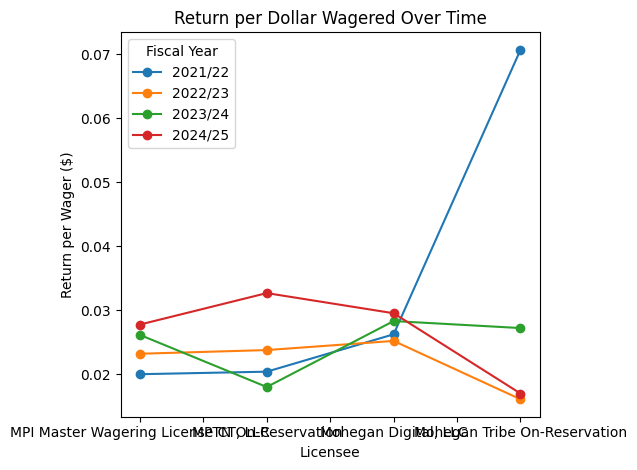

In [18]:
# What is the average monthly return per dollar wagered (GGR/Wagers) for each licensee, and how does this metric trend across fiscal years?
# Return per Dollar Wagered ---
df['Return per Wager'] = df['Total Gross Gaming Revenue'] / df['Wagers']
return_summary = df.groupby(['Fiscal Year', 'Licensee'])['Return per Wager'].mean().unstack()
print("\nQ5: Average Return per Dollar Wagered by Fiscal Year:")
print(return_summary)

# Bivariate: Wagers vs. Return per Wager
plt.figure(figsize=(10,6))
return_summary.T.plot(kind='line', marker='o')
plt.title('Return per Dollar Wagered Over Time')
plt.xlabel('Licensee')
plt.ylabel('Return per Wager ($)')
plt.legend(title='Fiscal Year')
plt.tight_layout()
plt.show()




Q5 Multivariate: Average Return per Dollar Wagered by Fiscal Year
Licensee     MPI Master Wagering License CT, LLC  MPTN On-Reservation  \
Fiscal Year                                                             
2021/22                                 0.020046             0.020441   
2022/23                                 0.023240             0.023817   
2023/24                                 0.026182             0.018048   
2024/25                                 0.027801             0.032716   

Licensee     Mohegan Digital, LLC  Mohegan Tribe On-Reservation  
Fiscal Year                                                      
2021/22                  0.026277                      0.070721  
2022/23                  0.025244                      0.016133  
2023/24                  0.028346                      0.027255  
2024/25                  0.029569                      0.017031  


<Figure size 1200x600 with 0 Axes>

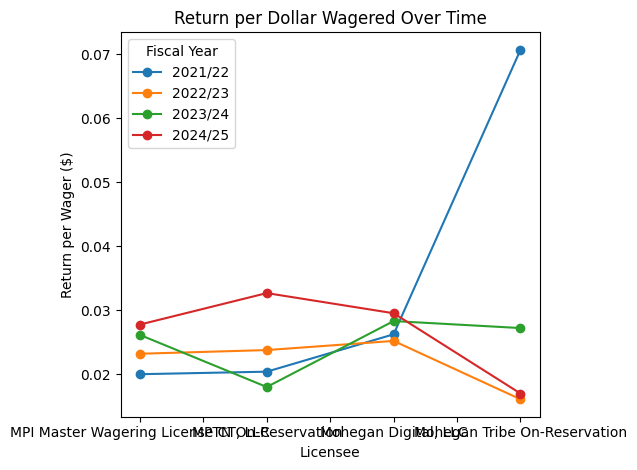

In [19]:
# Multivariate analysis: Return per Wager by Fiscal Year and Licensee
return_summary = df.groupby(['Fiscal Year', 'Licensee'])['Return per Wager'].mean().unstack()
print("\nQ5 Multivariate: Average Return per Dollar Wagered by Fiscal Year")
print(return_summary)

plt.figure(figsize=(12, 6))
return_summary.T.plot(kind='line', marker='o')
plt.title('Return per Dollar Wagered Over Time')
plt.xlabel('Licensee')
plt.ylabel('Return per Wager ($)')
plt.legend(title='Fiscal Year')
plt.tight_layout()
plt.show()

Are there specific months or seasons where business returns (GGR and Payments) consistently outperform others, and how can this inform resource allocation?

How do negative Online Casino Gaming Win/(Loss) occurrences affect overall returns for smaller licensees (Mohegan Tribe and MPTN), and what strategies could mitigate these losses?

In [26]:
Negative_win = df[df['Online Casino Gaming Win/(Loss)'] < 0].groupby('Licensee').agg({
    'Online Casino Gaming Win/(Loss)': 'sum',
    'Total Gross Gaming Revenue': 'sum'
}).reset_index()
print("\nQ7: Impact of Negative Win/(Loss) on Smaller Licensees:")
print(Negative_win)


Q7: Impact of Negative Win/(Loss) on Smaller Licensees:
                       Licensee  Online Casino Gaming Win/(Loss)  \
0           MPTN On-Reservation                           -21387   
1  Mohegan Tribe On-Reservation                          -138839   

   Total Gross Gaming Revenue  
0                      -21387  
1                     -138839  


What is the contribution of each licensee to total State payments relative to their share of Wagers, and does this indicate disparities in profitability?


Q8: Payment Contribution vs. Wager Share (%):
                              Licensee       Wagers  Payment (5)  Wager Share  \
0  MPI Master Wagering License CT, LLC  22906454350    101108667    58.414632   
1                  MPTN On-Reservation     66195874       260302     0.168809   
2                 Mohegan Digital, LLC  16193924180     79935149    41.296750   
3         Mohegan Tribe On-Reservation     46981776       195578     0.119810   

   Payment Share  
0      55.707348  
1       0.143417  
2      44.041478  
3       0.107757  


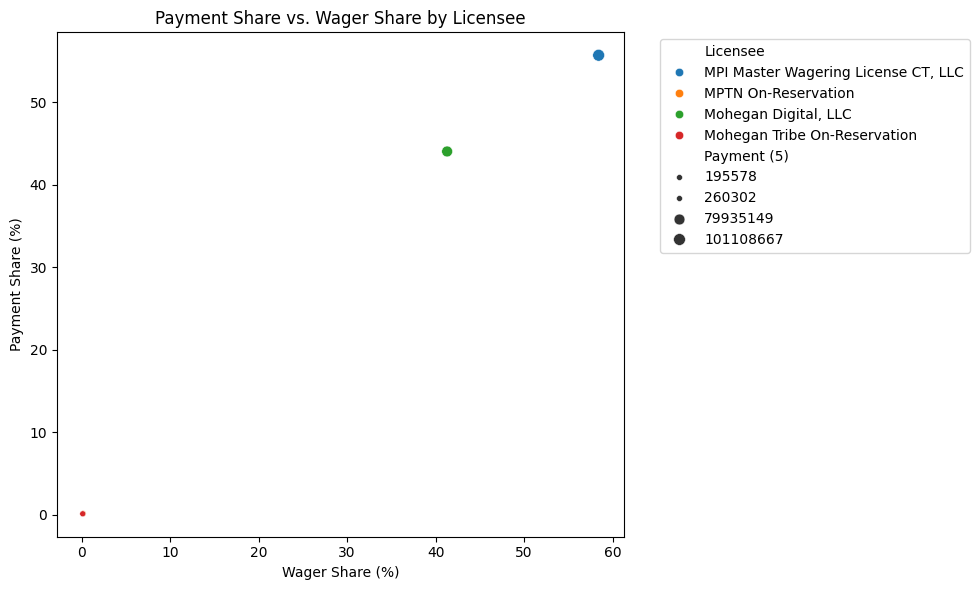

In [27]:
Total_wagers = df['Wagers'].sum()
Total_payments = df['Payment (5)'].sum()
Contribution = df.groupby('Licensee').agg({
    'Wagers': 'sum',
    'Payment (5)': 'sum'
}).reset_index()
Contribution['Wager Share'] = Contribution['Wagers'] / Total_wagers * 100
Contribution['Payment Share'] = Contribution['Payment (5)'] / Total_payments * 100
print("\nQ8: Payment Contribution vs. Wager Share (%):")
print(Contribution)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=Contribution, x='Wager Share', y='Payment Share', hue='Licensee', size='Payment (5)')
plt.title('Payment Share vs. Wager Share by Licensee')
plt.xlabel('Wager Share (%)')
plt.ylabel('Payment Share (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

How does the cost of cancelled wagers impact GGR and net returns, and are there operational inefficiencies that could be addressed to reduce these cancellations?

In [28]:
# Business Question 9: Cost of Cancelled Wagers
df['Cancelled Wager Impact'] = df['Cancelled Wagers'] / df['Wagers'] * 100
cancelled_impact = df.groupby('Licensee').agg({
    'Cancelled Wager Impact': 'mean',
    'Total Gross Gaming Revenue': 'mean'
}).reset_index()
print("\nQ9: Average Cancelled Wager Impact (% of Wagers) and GGR:")
print(cancelled_impact)


Q9: Average Cancelled Wager Impact (% of Wagers) and GGR:
                              Licensee  Cancelled Wager Impact  \
0  MPI Master Wagering License CT, LLC                0.062897   
1                  MPTN On-Reservation                0.003667   
2                 Mohegan Digital, LLC                0.048948   
3         Mohegan Tribe On-Reservation                0.002180   

   Total Gross Gaming Revenue  
0                1.478197e+07  
1                3.957586e+04  
2                1.168643e+07  
3                3.057077e+04  


What is the projected return on investment (ROI) for expanding operations, based on historical growth trends in Wagers and GGR for the top-performing licensees (MPI and Mohegan Digital)?


Q10: Projected ROI Based on Historical Growth Trends (%):
Average Annual Wager Growth: 17.80%
Average Annual GGR Growth: 28.67%


<Figure size 1200x600 with 0 Axes>

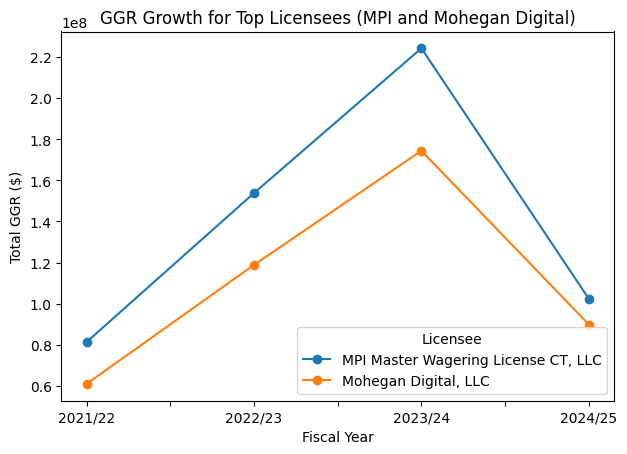

In [29]:
# --- Business Question 10: Projected ROI for Expansion ---
top_licensees = df[df['Licensee'].isin(['MPI Master Wagering License CT, LLC', 'Mohegan Digital, LLC'])]
growth_trends = top_licensees.groupby('Fiscal Year').agg({
    'Wagers': 'sum',
    'Total Gross Gaming Revenue': 'sum'
}).pct_change().mean() * 100  # Average annual growth
print("\nQ10: Projected ROI Based on Historical Growth Trends (%):")
print(f"Average Annual Wager Growth: {growth_trends['Wagers']:.2f}%")
print(f"Average Annual GGR Growth: {growth_trends['Total Gross Gaming Revenue']:.2f}%")

# Visualize growth trends for top licensees
top_trends = top_licensees.groupby(['Fiscal Year', 'Licensee'])['Total Gross Gaming Revenue'].sum().unstack()
plt.figure(figsize=(12, 6))
top_trends.plot(kind='line', marker='o')
plt.title('GGR Growth for Top Licensees (MPI and Mohegan Digital)')
plt.xlabel('Fiscal Year')
plt.ylabel('Total GGR ($)')
plt.legend(title='Licensee')
plt.tight_layout()
plt.show()